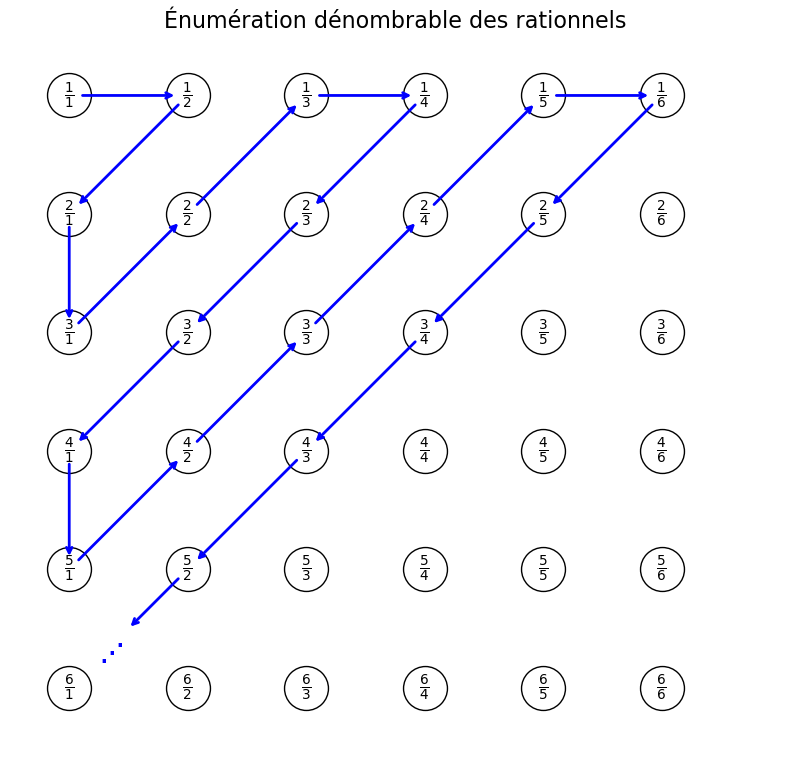

In [7]:
import matplotlib.pyplot as plt
import numpy as np

def enumeration(n_rows, n_cols):
    path = [(1, 1)]
    direction = 'right'

    while True:
        i, j = path[-1]

        if direction == 'right':
            if j + 1 > n_cols:
                break
            path.append((i, j + 1))
            i, j = path[-1]
            while i + 1 <= n_rows and j - 1 >= 1:
                i += 1
                j -= 1
                path.append((i, j))
            direction = 'down'

        elif direction == 'down':
            if i + 1 > n_rows:
                break
            path.append((i + 1, j))
            i, j = path[-1]
            while i - 1 >= 1 and j + 1 <= n_cols:
                i -= 1
                j += 1
                path.append((i, j))
            direction = 'right'

    return path

def chemin(n_rows=6, n_cols=6):
    fig, ax = plt.subplots(figsize=(8, 8))
    coords = {}

    # Placer les nombres
    for i in range(1, n_rows + 1):
        for j in range(1, n_cols + 1):
            x, y = j, -i
            coords[(i, j)] = (x, y)
            ax.scatter(x, y, s=1000, facecolors='white', edgecolors='black')
            ax.text(x, y, f"$\\frac{{{i}}}{{{j}}}$", ha='center', va='center', fontsize=14)

    path = enumeration(n_rows, n_cols)

    # Rayons
    fig.canvas.draw()
    points_to_data = ax.transData.inverted().transform([(10, 0)]) - ax.transData.inverted().transform([(0, 0)])
    r = abs(points_to_data[0][0])

    # Flèches
    for (i1, j1), (i2, j2) in zip(path[:-2], path[1:-1]):
        x1, y1 = coords[(i1, j1)]
        x2, y2 = coords[(i2, j2)]

        dx = x2 - x1
        dy = y2 - y1
        length = np.hypot(dx, dy)
        ux, uy = dx / length, dy / length

        start_x = x1 + r * ux
        start_y = y1 + r * uy
        end_x = x2 - r * ux
        end_y = y2 - r * uy

        ax.annotate('', xy=(end_x, end_y), xytext=(start_x, start_y),
                    arrowprops=dict(arrowstyle='->', lw=2, color='blue'))

    # Dernière flèche mesure moitié moins
    if len(path) > 1:
        i1, j1 = path[-2]
        i2, j2 = path[-1]

        x1, y1 = coords[(i1, j1)]
        x2, y2 = coords[(i2, j2)]

        dx = x2 - x1
        dy = y2 - y1
        length = np.hypot(dx, dy)
        ux, uy = dx / length, dy / length

        start_x = x1 + r * ux
        start_y = y1 + r * uy
        half_length = (length - 2 * r) / 2
        end_x = start_x + half_length * ux
        end_y = start_y + half_length * uy

        ax.annotate('', xy=(end_x, end_y), xytext=(start_x, start_y),
                    arrowprops=dict(arrowstyle='->', lw=2, color='blue'))

        # Trois petits points
        dot_spacing = 0.1  # espacement
        for k in range(1, 4):
            dot_x = end_x + k * dot_spacing * ux
            dot_y = end_y + k * dot_spacing * uy
            ax.text(dot_x, dot_y, '.', fontsize=24, ha='center', va='center', color='blue')


    ax.set_xlim(0.5, n_cols + 1)
    ax.set_ylim(-n_rows - 0.5, -0.5)
    ax.set_aspect('equal')
    ax.axis('off')
    plt.title("Énumération dénombrable des rationnels", fontsize=16)
    plt.tight_layout()
    plt.savefig("enumeration_rationel.svg", format="svg")
    plt.show()
if __name__ == "__main__":
    chemin()
